# Coding Ninjas 10X Club AI/ML Recruitment 2026
## Task 2: Neural Network
### MNIST Digit Classification

This notebook builds a simple fully connected neural network for classifying MNIST handwritten digits. It includes data preprocessing, baseline model training, evaluation using a confusion matrix, and an experiment comparing two hidden-layer sizes.

## 1. Import Libraries

TensorFlow/Keras provides the dataset and neural-network tools. NumPy is used for array operations, and Matplotlib is used to visualize images and training history.

In [3]:
import os

# Set seeds before creating/loading model-related objects for reproducible runs.
os.environ["PYTHONHASHSEED"] = "42"

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(42)
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## 2. Dataset Understanding

**MNIST** (Modified National Institute of Standards and Technology) is a dataset of grayscale handwritten digit images. Each image is **28 × 28 pixels**, so it contains 784 pixel values. There are **10 classes**: the labels `0` through `9`, where each label is the digit written in the image.

## 3. Load the MNIST Dataset

Keras downloads the dataset on first use (if it is not already cached) and returns predefined training and testing splits.

In [4]:
# Load MNIST images and their integer digit labels.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## 4. Inspect the Dataset

The shapes below show the number of images and image dimensions. Labels are one integer per image.

In [5]:
print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape  :", x_test.shape)
print("Testing labels shape :", y_test.shape)

Training data shape : (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape  : (10000, 28, 28)
Testing labels shape : (10000,)


## 5. Visualize Sample Images

Each image is displayed with its corresponding digit label.

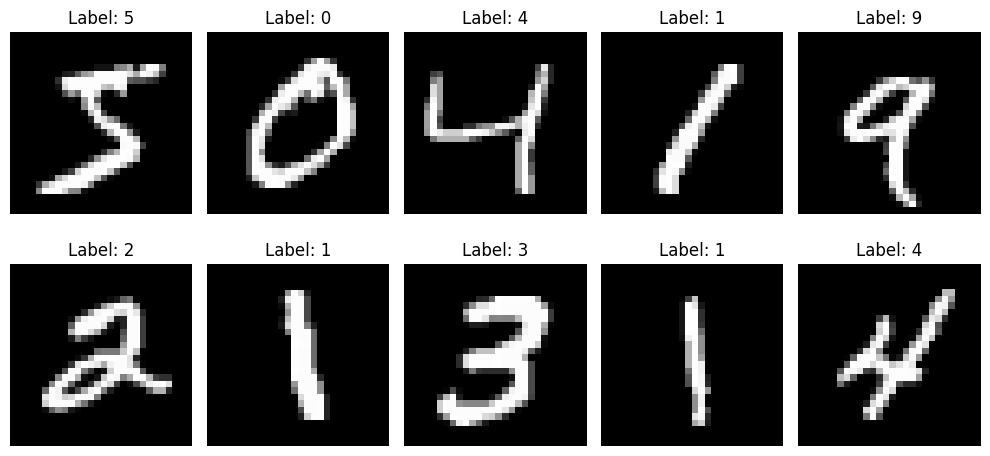

In [6]:
# Show a small selection of training examples.
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for index, axis in enumerate(axes.flat):
    axis.imshow(x_train[index], cmap="gray")
    axis.set_title(f"Label: {y_train[index]}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## 6. Data Preprocessing

Pixel values originally range from 0 to 255. Dividing by 255 converts them to the range 0 to 1, which makes training more stable. Because this baseline uses fully connected `Dense` layers, each 28 × 28 image is flattened into a vector of **784 features**.

In [7]:
# Normalize pixels to the range [0, 1] and flatten 28 x 28 images to 784 features.
x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

x_train_flat = x_train_normalized.reshape(x_train_normalized.shape[0], 28 * 28)
x_test_flat = x_test_normalized.reshape(x_test_normalized.shape[0], 28 * 28)

print("Training data after preprocessing:", x_train_flat.shape)
print("Testing data after preprocessing :", x_test_flat.shape)

Training data after preprocessing: (60000, 784)
Testing data after preprocessing : (10000, 784)


## 7. Build the Simple Baseline Neural Network

Architecture:

```text
28×28 image
     ↓
Flatten → 784
     ↓
Dense(128, ReLU)
     ↓
Dense(10, Softmax)
```

The preprocessing cell already flattens the images, so the model input has 784 features. The final softmax layer returns probabilities for digits 0–9.

In [8]:
# Create a simple fully connected neural network (not a CNN).
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

## 8. Display the Model Summary

This confirms the layers, output shapes, and number of trainable parameters.

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

`Adam` updates the model weights during training. The labels are integers rather than one-hot encoded vectors, so `sparse_categorical_crossentropy` is used.

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## 10. Train the Model

The model trains for 10 epochs with batches of 32 images. Ten percent of the training data is held out automatically for validation.

In [11]:
history = model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9239 - loss: 0.2672 - val_accuracy: 0.9632 - val_loss: 0.1248
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9648 - loss: 0.1164 - val_accuracy: 0.9705 - val_loss: 0.0994
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9764 - loss: 0.0801 - val_accuracy: 0.9705 - val_loss: 0.0950
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9820 - loss: 0.0606 - val_accuracy: 0.9740 - val_loss: 0.0900
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9869 - loss: 0.0455 - val_accuracy: 0.9753 - val_loss: 0.0889
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9905 - loss: 0.0346 - val_accuracy: 0.9772 - val_loss: 0.0847
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9928 - loss: 0.0263 - val_accuracy: 0.9762 - val_loss: 0.0939
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9948 - loss: 0.0202 - 

## 11. Evaluate on the Test Dataset

The test set was not used for training or validation, so it provides an unbiased initial evaluation.

In [12]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.1062
Test accuracy: 0.9728


## 12. Plot Training History

These plots compare training and validation accuracy, then training and validation loss, across epochs.

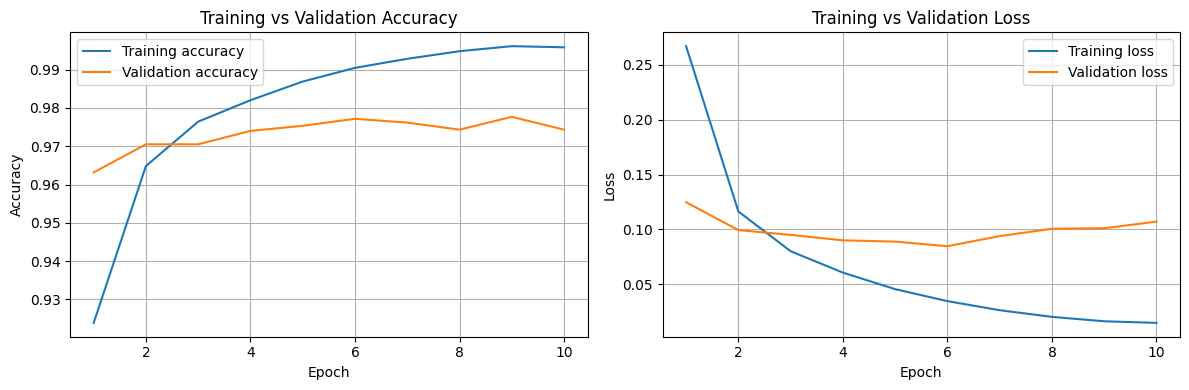

In [13]:
epochs = range(1, len(history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history.history["accuracy"], label="Training accuracy")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history.history["loss"], label="Training loss")
axes[1].plot(epochs, history.history["val_loss"], label="Validation loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 13. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each digit class. The rows represent the actual labels, while the columns represent the predicted labels.


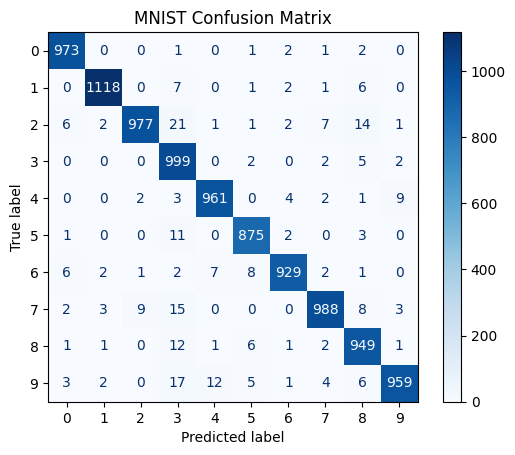

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get predicted probabilities for the test images
y_pred_prob = model.predict(x_test_flat, verbose=0)

# Convert probabilities into predicted digit labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(cmap="Blues", values_format="d")
plt.title("MNIST Confusion Matrix")
plt.show()

In [15]:
# Experiment: Increase the hidden layer from 128 to 256 neurons

experiment_model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

experiment_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
experiment_history = experiment_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9308 - loss: 0.2375 - val_accuracy: 0.9682 - val_loss: 0.1091
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9708 - loss: 0.0979 - val_accuracy: 0.9728 - val_loss: 0.0905
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9811 - loss: 0.0636 - val_accuracy: 0.9747 - val_loss: 0.0862
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9874 - loss: 0.0430 - val_accuracy: 0.9745 - val_loss: 0.0911
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9921 - loss: 0.0296 - val_accuracy: 0.9785 - val_loss: 0.0894
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9938 - loss: 0.0213 - val_accuracy: 0.9770 - val_loss: 0.0927
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9949 - loss: 0.0172 - val_accuracy: 0.9767 - val_loss: 0.1056
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9959 - loss: 0.

In [18]:
baseline_test_loss, baseline_test_accuracy = model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print(f"Test loss: {baseline_test_loss:.4f}")
print(f"Test accuracy: {baseline_test_accuracy:.4f}")

Test loss: 0.1062
Test accuracy: 0.9728


In [24]:
experiment_test_loss, experiment_test_accuracy = experiment_model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

# Compare baseline and experimental model results

baseline_accuracy = baseline_test_accuracy
baseline_loss = baseline_test_loss

print("Model Comparison")
print("-" * 40)
print(f"Baseline (128 neurons) - Accuracy: {baseline_accuracy:.4f}")
print(f"Experiment (256 neurons) - Accuracy: {experiment_test_accuracy:.4f}")
print()
print(f"Baseline (128 neurons) - Loss: {baseline_loss:.4f}")
print(f"Experiment (256 neurons) - Loss: {experiment_test_loss:.4f}")
print()
print(f"Accuracy improvement: {(experiment_test_accuracy - baseline_accuracy) * 100:.2f} percentage points")
print(f"Loss change: {experiment_test_loss - baseline_loss:.4f}")

Model Comparison
----------------------------------------
Baseline (128 neurons) - Accuracy: 0.9728
Experiment (256 neurons) - Accuracy: 0.9754

Baseline (128 neurons) - Loss: 0.1062
Experiment (256 neurons) - Loss: 0.1016

Accuracy improvement: 0.26 percentage points
Loss change: -0.0046


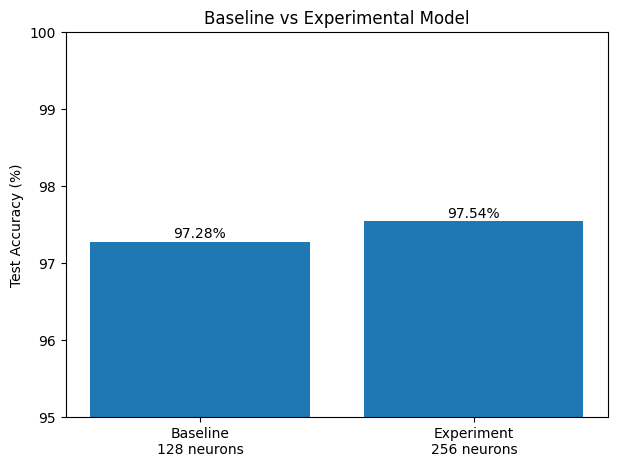

In [23]:
# Visual comparison of test accuracy

models = ["Baseline\n128 neurons", "Experiment\n256 neurons"]
accuracies = [baseline_accuracy * 100, experiment_test_accuracy * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Baseline vs Experimental Model")
plt.ylim(95, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

## 14. Experiment and Comparison

### Experiment

For the experiment, the number of neurons in the hidden layer was increased from 128 to 256.

The baseline architecture was:

784 → Dense(128, ReLU) → Dense(10, Softmax)

The experimental architecture was:

784 → Dense(256, ReLU) → Dense(10, Softmax)

All other training settings were kept the same:
- Optimizer: Adam
- Loss function: Sparse Categorical Cross-Entropy
- Epochs: 10
- Batch size: 32
- Validation split: 0.1

### Results

| Metric | Baseline (128 neurons) | Experiment (256 neurons) |
|---|---:|---:|
| Test Accuracy | 97.28% | 97.54% |
| Test Loss | 0.1062 | 0.1016 |
### Observation

Increasing the hidden-layer size from 128 to 256 neurons improved the test accuracy from 97.28% to 97.54% and reduced the test loss from 0.1062 to 0.1016.

The larger hidden layer provided the model with additional capacity to learn patterns in the handwritten digit images. In this run, that additional capacity resulted in a small improvement in performance on the unseen test data.

However, increasing the number of neurons also increases the number of model parameters and computational requirements. A larger model does not automatically guarantee better generalization.

# 15. Key Findings

- The baseline neural network achieved a test accuracy of 97.28% with a test loss of 0.1062.
- The confusion matrix shows that most predictions lie on the diagonal, indicating that most digits were classified correctly.
- Some misclassifications occurred between handwritten digits, with one of the largest observed confusions being actual digit 2 predicted as digit 3.
- Increasing the hidden-layer size from 128 to 256 neurons improved the test accuracy to 97.54%.
- The experimental model reduced the test loss from 0.1062 to 0.1016.
- In this experiment, increasing the hidden-layer capacity produced a 0.26 percentage-point improvement in test accuracy.

# 16. Limitations

- The model is a simple fully connected neural network and does not explicitly take advantage of the spatial structure of images.
- Only one model experiment was performed.
- The number of epochs and other training settings were kept fixed, so other configurations may produce different results.
- The experiment was performed only on the MNIST dataset, so the results may not generalize to more complex image-classification problems.

# 17. Possible Future Improvements

- Experiment with different learning rates, batch sizes, and numbers of epochs.
- Use regularization techniques such as dropout to investigate whether generalization can be improved.
- Try a Convolutional Neural Network (CNN), which is designed to learn spatial patterns in images.
- Perform additional hyperparameter experiments and compare their effects systematically.
- Evaluate the model on more challenging handwritten-digit datasets.

# 18. Conclusion

A simple fully connected neural network was successfully trained to classify handwritten MNIST digits. The baseline model achieved 97.28% test accuracy. Increasing the hidden-layer size from 128 to 256 neurons improved the test accuracy to 97.54% and reduced the test loss from 0.1062 to 0.1016.

The experiment demonstrates how changing a model hyperparameter can affect its performance. In this experiment, the larger hidden layer produced a small improvement on the unseen test data, while the results also show that there is still room for improvement through different architectures, regularization, and further hyperparameter tuning.

In [22]:
# Rebuild and evaluate the experimental model in one cell

experiment_model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

experiment_history = experiment_model.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

experiment_test_loss, experiment_test_accuracy = experiment_model.evaluate(
    x_test_flat,
    y_test,
    verbose=0
)

print(f"Experiment test loss: {experiment_test_loss:.4f}")
print(f"Experiment test accuracy: {experiment_test_accuracy:.4f}")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9307 - loss: 0.2371 - val_accuracy: 0.9690 - val_loss: 0.1065
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9722 - loss: 0.0957 - val_accuracy: 0.9725 - val_loss: 0.0884
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9817 - loss: 0.0618 - val_accuracy: 0.9730 - val_loss: 0.0852
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9879 - loss: 0.0414 - val_accuracy: 0.9770 - val_loss: 0.0852
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9919 - loss: 0.0290 - val_accuracy: 0.9753 - val_loss: 0.0935
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9939 - loss: 0.0218 - val_accuracy: 0.9745 - val_loss: 0.0991
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9953 - loss: 0.0162 - val_accuracy: 0.9718 - val_loss: 0.1137
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9960 - loss: 0.0